<a href="https://colab.research.google.com/github/EfiDefiyati/Modul-Praktikum-Deep-Learning/blob/main/notebooks/modul-02/M02_123450005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 2: Backpropagation dan Automatic Differentiation

**Nama:** Efi Defiyati  
**NIM:** 123450005  
**Kelas:** RC  
**Tanggal:** 2026-09-22  

Simpan berkas ini sebagai `M02_NIM.ipynb` sebelum mulai mengerjakan.

## Petunjuk

1. Ganti seluruh penanda `TODO`. Jangan menghapus sel pemeriksaan.
2. Nilai Kasus 1 tidak boleh diubah; seluruh angka pada modul mengacu padanya.
3. Gunakan `float64` untuk semua perhitungan gradien.
4. Tuliskan turunan manual pada sel markdown, bukan hanya di kertas.
5. Notebook harus lolos *Restart Kernel and Run All* sebelum dikumpulkan.
6. Luaran: `M02_NIM.ipynb`, `M02_NIM.pdf`, dan `M02_NIM_metrics.csv`.

In [12]:
import platform
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

NIM = '123450005'                # NIM mahasiswa
SEED = int(str(NIM)[-4:]) if str(NIM).isdigit() else 42   # seed individual
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
torch.set_default_dtype(torch.float64)
pd.set_option('display.precision', 8)
print({'python': platform.python_version(), 'numpy': np.__version__,
       'torch': torch.__version__, 'device': str(DEVICE), 'seed': SEED})

{'python': '3.13.15', 'numpy': '2.1.3', 'torch': '2.11.0+cu128', 'device': 'cuda', 'seed': 5}


## A. Pre lab (10 poin)

Jawab sebelum sesi praktikum dimulai.

1. **Gradien lokal vs gradien total pada satu simpul.** Gradien lokal adalah turunan keluaran suatu simpul terhadap masukannya sendiri, dihitung hanya dari operasi pada simpul itu, tanpa memedulikan apa yang terjadi setelahnya di dalam graf. Gradien total adalah turunan loss akhir terhadap simpul tersebut. Nilainya diperoleh dengan mengalikan gradien lokal simpul itu dengan gradien total dari simpul berikutnya, sesuai aturan rantai. Dengan begitu, gradien total merupakan hasil akumulasi seluruh gradien lokal di sepanjang jalur dari loss sampai ke simpul yang bersangkutan.

2. **Mengapa `backward()` hanya dapat dipanggil pada tensor skalar.** Konsep turunan searah hanya terdefinisi secara langsung ketika besaran yang diturunkan berupa satu angka tunggal, yaitu skalar. Apabila keluarannya berbentuk vektor atau matriks, PyTorch tidak memiliki informasi tentang bobot yang harus dipakai untuk menggabungkan turunan pada setiap komponen keluaran tersebut. Karena itu, sebelum `backward()` dijalankan pada keluaran non skalar, pengguna harus menyediakan vektor gradien awal melalui argumen `gradient`, atau lebih sederhana lagi, meringkas keluaran itu menjadi skalar terlebih dahulu, misalnya dengan menjumlahkan atau merata ratakan nilainya.

3. **Isi `.grad` bila `backward()` dipanggil dua kali tanpa `zero_grad()`.** PyTorch menjumlahkan gradien baru ke atas nilai `.grad` yang sudah tersimpan, bukan menimpanya. Jadi apabila `backward()` dipanggil dua kali berturut turut pada perhitungan loss yang identik, nilai `.grad` menjadi dua kali lipat dari hasil satu kali pemanggilan, dan akan terus bertambah pada setiap pemanggilan berikutnya selama tidak dibersihkan.

4. **Mengapa turunan BCE with logits terhadap logit berbentuk $p-y$, bukan $-y/p$.** Turunan loss BCE terhadap probabilitas $p$ memang berbentuk $-y/p + (1-y)/(1-p)$. Akan tetapi yang dicari di sini adalah turunan terhadap logit $z$, bukan terhadap $p$. Karena $p$ sendiri merupakan fungsi sigmoid dari $z$, aturan rantai mengalikan turunan loss terhadap $p$ dengan turunan sigmoid terhadap $z$, yaitu $p(1-p)$. Ketika kedua faktor tersebut dikalikan, sebagian besar suku saling meniadakan secara aljabar sehingga hasil akhirnya menyederhana menjadi $p-y$. Bentuk ini jauh lebih ringkas dan juga lebih stabil secara numerik karena tidak pernah membagi dengan bilangan yang mendekati nol.

**Graf komputasi Kasus 1.** Urutan simpul dari $\mathbf{x}$ sampai $\mathcal{L}$, beserta gradien lokal setiap simpul, adalah sebagai berikut.

1. $\mathbf{x} \;\xrightarrow{\;\mathbf{W}^{(1)},\, \mathbf{b}^{(1)}\;}\; \mathbf{z}^{(1)} = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}$, dengan gradien lokal $\partial \mathbf{z}^{(1)}/\partial \mathbf{W}^{(1)} = \mathbf{x}$, $\partial \mathbf{z}^{(1)}/\partial \mathbf{b}^{(1)} = 1$, dan $\partial \mathbf{z}^{(1)}/\partial \mathbf{x} = \mathbf{W}^{(1)}$.
2. $\mathbf{z}^{(1)} \xrightarrow{\text{ReLU}} \mathbf{h} = \max(\mathbf{z}^{(1)}, 0)$, dengan gradien lokal $1$ pada komponen yang bernilai positif dan $0$ pada komponen yang bernilai nol atau negatif.
3. $\mathbf{h} \;\xrightarrow{\;\mathbf{W}^{(2)},\, b^{(2)}\;}\; z^{(2)} = \mathbf{W}^{(2)}\mathbf{h} + b^{(2)}$, dengan gradien lokal $\partial z^{(2)}/\partial \mathbf{W}^{(2)} = \mathbf{h}$, $\partial z^{(2)}/\partial b^{(2)} = 1$, dan $\partial z^{(2)}/\partial \mathbf{h} = \mathbf{W}^{(2)}$.
4. $z^{(2)} \xrightarrow{\text{sigmoid}} p = 1/(1+e^{-z^{(2)}})$, dengan gradien lokal $p(1-p)$.
5. $p \xrightarrow{\text{BCE}} \mathcal{L} = -\big(y\log p + (1-y)\log(1-p)\big)$, dengan gradien lokal $\partial \mathcal{L}/\partial p = -y/p + (1-y)/(1-p)$.

Pada implementasinya, langkah keempat dan kelima digabung menjadi satu fungsi `BCEWithLogitsLoss`, sehingga gradien terhadap logit langsung diperoleh sebagai $p - y$ tanpa harus melalui pembagian yang rawan galat numerik.

## B. Turunan manual - 20 poin

Kasus 1 memakai nilai tetap berikut:

$$\mathbf{x}=\begin{bmatrix}2 & -1\end{bmatrix},\quad
\mathbf{W}^{(1)}=\begin{bmatrix}0.5 & -0.5\\ 1 & 1\end{bmatrix},\quad
\mathbf{b}^{(1)}=\begin{bmatrix}0 & 0\end{bmatrix},\quad
\mathbf{W}^{(2)}=\begin{bmatrix}2 & -1\end{bmatrix},\quad
b^{(2)}=0.5,\quad y=1$$

Tuliskan penurunan Anda **berurutan** di sini, satu baris satu langkah:

1. $\partial\mathcal{L}/\partial z^{(2)} = p - y = 0{,}924142 - 1 = -0{,}075858$
2. $\partial\mathcal{L}/\partial \mathbf{W}^{(2)} = (\partial\mathcal{L}/\partial z^{(2)}) \cdot \mathbf{h} = -0{,}075858 \times [1{,}5\;\;1] = [-0{,}113787\;\; -0{,}075858]$
3. $\partial\mathcal{L}/\partial b^{(2)} = \partial\mathcal{L}/\partial z^{(2)} = -0{,}075858$
4. $\partial\mathcal{L}/\partial \mathbf{h} = (\partial\mathcal{L}/\partial z^{(2)}) \cdot \mathbf{W}^{(2)} = -0{,}075858 \times [2\;\; -1] = [-0{,}151716\;\; 0{,}075858]$
5. $\partial\mathcal{L}/\partial \mathbf{z}^{(1)} = \partial\mathcal{L}/\partial \mathbf{h} \odot \mathbb{1}[\mathbf{z}^{(1)}>0]$. Karena $\mathbf{z}^{(1)}=[1{,}5\;\;1]$ seluruhnya positif, maskernya adalah $[1\;\;1]$ sehingga $\partial\mathcal{L}/\partial \mathbf{z}^{(1)} = [-0{,}151716\;\; 0{,}075858]$
6. $\partial\mathcal{L}/\partial \mathbf{W}^{(1)} = (\partial\mathcal{L}/\partial \mathbf{z}^{(1)}) \otimes \mathbf{x} = \begin{bmatrix}-0{,}151716\\ 0{,}075858\end{bmatrix} \begin{bmatrix}2 & -1\end{bmatrix} = \begin{bmatrix}-0{,}303433 & 0{,}151716\\ 0{,}151716 & -0{,}075858\end{bmatrix}$
7. $\partial\mathcal{L}/\partial \mathbf{b}^{(1)} = \partial\mathcal{L}/\partial \mathbf{z}^{(1)} = [-0{,}151716\;\; 0{,}075858]$

Shape setiap gradien: `dz2` adalah skalar, `dW2` berukuran $1\times2$ mengikuti $\mathbf{W}^{(2)}$, `db2` skalar, `dh` dan `dz1` masing masing berukuran $1\times2$, `dW1` berukuran $2\times2$ mengikuti $\mathbf{W}^{(1)}$, dan `db1` berukuran $1\times2$ mengikuti $\mathbf{b}^{(1)}$. Setiap gradien selalu berbentuk sama dengan parameter pasangannya, sehingga `dW1` tidak boleh keliru menjadi $2\times1$.

In [2]:
x  = np.array([2.0, -1.0])
W1 = np.array([[0.5, -0.5], [1.0, 1.0]])
b1 = np.array([0.0, 0.0])
W2 = np.array([2.0, -1.0])
b2 = 0.5
y  = 1.0

def forward(x, W1, b1, W2, b2, y):
    # Mengembalikan dict berisi z1, h, z2, p, dan loss.
    z1 = W1 @ x + b1
    h = np.maximum(z1, 0.0)
    z2 = W2 @ h + b2
    p = 1.0 / (1.0 + np.exp(-z2))
    loss = -(y * np.log(p) + (1 - y) * np.log(1 - p))
    return {'z1': z1, 'h': h, 'z2': z2, 'p': p, 'loss': loss}

nilai = forward(x, W1, b1, W2, b2, y)
print({k: np.round(v, 6) for k, v in nilai.items()})

# Pemeriksaan wajib: jangan diubah.
assert np.allclose(nilai['z1'], [1.5, 1.0]), 'z1 belum benar'
assert np.isclose(nilai['z2'], 2.5), 'logit belum benar'
assert np.isclose(nilai['loss'], 0.0788897, atol=1e-6), 'loss belum benar'
print('forward pass sesuai Kasus 1')

{'z1': array([1.5, 1. ]), 'h': array([1.5, 1. ]), 'z2': np.float64(2.5), 'p': np.float64(0.924142), 'loss': np.float64(0.07889)}
forward pass sesuai Kasus 1


In [3]:
def backward(x, W1, W2, y, nilai):
    # Mengembalikan dict gradien untuk 'W1', 'b1', 'W2', 'b2'.
    # Urutan pengerjaan: dz2 -> (dW2, db2, dh) -> dz1 -> (dW1, db1).
    z1, h, p = nilai['z1'], nilai['h'], nilai['p']

    dz2 = p - y                      # turunan BCE-with-logits terhadap logit
    dW2 = dz2 * h                    # gradien lokal linear: h
    db2 = dz2                        # gradien lokal linear: 1
    dh  = dz2 * W2                   # gradien lokal linear: W2

    dz1 = dh * (z1 > 0)              # gradien lokal ReLU: 1 bila z1 > 0
    dW1 = np.outer(dz1, x)           # baris ke-i dikalikan x
    db1 = dz1

    return {'dz2': dz2, 'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

grad_manual = backward(x, W1, W2, y, nilai)
for nama, v in grad_manual.items():
    print(f'{nama:>3}: {np.round(v, 7)}')

# Pemeriksaan wajib: dua angka kunci dari modul.
assert np.allclose(grad_manual['W2'], [-0.1137873, -0.0758582], atol=1e-6)
assert grad_manual['W1'].shape == W1.shape, 'shape dW1 harus sama dengan W1'
print('gradien manual sesuai angka acuan')

dz2: -0.0758582
 W1: [[-0.3034327  0.1517164]
 [ 0.1517164 -0.0758582]]
 b1: [-0.1517164  0.0758582]
 W2: [-0.1137873 -0.0758582]
 b2: -0.0758582
gradien manual sesuai angka acuan


## C. Autograd - 20 poin

Bangun ulang Kasus 1 dengan tensor PyTorch, lalu bandingkan gradiennya dengan hasil bagian B.

In [4]:
tW1 = torch.tensor(W1, requires_grad=True)
tb1 = torch.tensor(b1, requires_grad=True)
tW2 = torch.tensor(W2, requires_grad=True)
tb2 = torch.tensor(b2, requires_grad=True)
tx, ty = torch.tensor(x), torch.tensor(y)
kriteria = nn.BCEWithLogitsLoss()

def forward_torch():
    # Menghitung loss dengan BCEWithLogitsLoss pada LOGIT (bukan probabilitas).
    z1 = tW1 @ tx + tb1
    h = torch.relu(z1)
    z2 = tW2 @ h + tb2
    return kriteria(z2, ty)

loss = forward_torch()
loss.backward()

for nama, t in [('W1', tW1), ('b1', tb1), ('W2', tW2), ('b2', tb2)]:
    selisih = np.max(np.abs(t.grad.numpy() - grad_manual[nama]))
    print(f'{nama}: autograd = {np.round(t.grad.numpy(), 7)}   selisih maks = {selisih:.2e}')
    assert selisih < 1e-10, f'gradien {nama} belum cocok dengan hasil manual'
print('autograd cocok dengan backward manual')

W1: autograd = [[-0.3034327  0.1517164]
 [ 0.1517164 -0.0758582]]   selisih maks = 0.00e+00
b1: autograd = [-0.1517164  0.0758582]   selisih maks = 0.00e+00
W2: autograd = [-0.1137873 -0.0758582]   selisih maks = 0.00e+00
b2: autograd = -0.0758582   selisih maks = 0.00e+00
autograd cocok dengan backward manual


In [5]:
# Memanggil backward() sekali lagi TANPA menghapus gradien terlebih dahulu.
loss_kedua = forward_torch()
loss_kedua.backward()
print('setelah backward kedua :', np.round(tW2.grad.numpy(), 7))

for t in (tW1, tb1, tW2, tb2):    # cara menghapus gradien secara manual
    t.grad = None

forward_torch().backward()
print('setelah gradien dihapus:', np.round(tW2.grad.numpy(), 7))

setelah backward kedua : [-0.2275745 -0.1517164]
setelah gradien dihapus: [-0.1137873 -0.0758582]


**Penjelasan akumulasi gradien.** Setelah `backward()` dipanggil kedua kalinya tanpa dibersihkan lebih dulu, nilai `tW2.grad` menjadi tepat dua kali lipat dari nilai satu kali pemanggilan, karena PyTorch menambahkan gradien baru ke atas gradien lama, bukan menggantinya. Setelah gradien dihapus dengan mengatur `.grad = None` pada setiap parameter dan `backward()` dijalankan ulang, nilainya kembali ke besaran satu kali pemanggilan, yaitu sama dengan hasil bagian B dan bagian C sebelumnya.

Kaitannya dengan `optimizer.zero_grad()` pada training loop adalah sebagai berikut. Setiap epoch semestinya memakai gradien yang dihitung hanya dari batch pada epoch itu. Apabila `zero_grad()` tidak dipanggil, gradien dari epoch sebelumnya akan ikut menumpuk dan tercampur dengan gradien epoch saat ini, sehingga langkah pembaruan parameter memakai jumlah gradien dari seluruh epoch yang sudah berlalu, bukan gradien epoch tersebut saja. Akibatnya proses belajar menjadi tidak stabil dan langkah pembaruan membesar tanpa terkendali seiring bertambahnya epoch.

## D. Gradient checking - 20 poin

Bandingkan gradien analitik dengan selisih terpusat:

$$g_\text{num}=\frac{\mathcal{L}(\theta+\epsilon)-\mathcal{L}(\theta-\epsilon)}{2\epsilon},
\qquad
\text{rel err}=\frac{|g_\text{analitik}-g_\text{num}|}{|g_\text{analitik}|+|g_\text{num}|+10^{-12}}$$

Ambang lulus: seluruh baris di bawah $10^{-5}$.

In [6]:
EPS = 1e-5

def loss_dengan(param, i, delta):
    # Menyalin parameter, menggeser satu komponen sebesar delta, mengembalikan loss.
    p = {'W1': W1.copy(), 'b1': b1.copy(), 'W2': W2.copy(), 'b2': np.array(b2)}
    p[param][i] += delta
    return forward(x, p['W1'], p['b1'], p['W2'], float(p['b2']), y)['loss']

def finite_difference(param, i):
    # Mengembalikan gradien numerik dengan selisih terpusat.
    return (loss_dengan(param, i, EPS) - loss_dengan(param, i, -EPS)) / (2 * EPS)

indeks = ([('W1', (0, 0)), ('W1', (0, 1)), ('W1', (1, 0)), ('W1', (1, 1))]
          + [('b1', (0,)), ('b1', (1,))]
          + [('W2', (0,)), ('W2', (1,))]
          + [('b2', ())])

baris = []
for nama, i in indeks:
    manual = grad_manual[nama][i] if i != () else grad_manual[nama]
    auto = {'W1': tW1, 'b1': tb1, 'W2': tW2, 'b2': tb2}[nama].grad.numpy()
    auto = auto[i] if i != () else auto
    numerik = finite_difference(nama, i)
    rel = abs(manual - numerik) / (abs(manual) + abs(numerik) + 1e-12)
    baris.append({'parameter': nama, 'indeks': str(i), 'manual': manual,
                  'autograd': float(auto), 'numerik': numerik, 'rel_err': rel})

tabel = pd.DataFrame(baris)
print(tabel.to_string(index=False))
print('\nrelative error maksimum:', tabel['rel_err'].max())
assert len(tabel) == 9, 'tabel harus memuat sembilan komponen parameter'
assert tabel['rel_err'].max() < 1e-5, 'masih ada baris yang melampaui ambang'

parameter indeks      manual    autograd     numerik        rel_err
       W1 (0, 0) -0.30343272 -0.30343272 -0.30343272 1.00453007e-10
       W1 (0, 1)  0.15171636  0.15171636  0.15171636 2.95622632e-11
       W1 (1, 0)  0.15171636  0.15171636  0.15171636 2.95622632e-11
       W1 (1, 1) -0.07585818 -0.07585818 -0.07585818 5.73360674e-11
       b1   (0,) -0.15171636 -0.15171636 -0.15171636 2.95622632e-11
       b1   (1,)  0.07585818  0.07585818  0.07585818 5.73360674e-11
       W2   (0,) -0.11378727 -0.11378727 -0.11378727 6.76755052e-11
       W2   (1,) -0.07585818 -0.07585818 -0.07585818 5.73360674e-11
       b2     () -0.07585818 -0.07585818 -0.07585818 5.73360674e-11

relative error maksimum: 1.004530066507852e-10


In [7]:
# Menyimpan tabel ke berkas metrik.
tabel.insert(0, 'run_id', 'gradcheck')
tabel.insert(1, 'seed', SEED)
tabel.to_csv(f'M02_{NIM}_metrics.csv', index=False)
print('tersimpan')

tersimpan


**Checkpoint menit ke-95.** Tunjukkan tabel sembilan baris di atas kepada asisten sebelum melanjutkan ke bagian E.

## E. Diagnosis training loop - 20 poin

Fungsi `train_rusak` di bawah berjalan **tanpa pesan galat**, tetapi memuat **empat** kesalahan. Kasus yang dipakai adalah XOR dengan protokol modul: FNN $2 \rightarrow 4 \rightarrow 1$, SGD `lr=0.1`, 400 epoch, satu batch penuh.

In [8]:
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

def train_rusak(epoch: int = 400, lr: float = 0.1):
    seed_everything(SEED)
    model = nn.Sequential(
        nn.Linear(2, 4),
        nn.Linear(4, 1),
    )
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    kriteria = nn.BCEWithLogitsLoss()
    riwayat = []

    for _ in range(epoch):
        logits = model(X_xor)
        loss = kriteria(torch.sigmoid(logits), y_xor)
        opt.step()
        loss.backward()
        riwayat.append(loss.item())
    return model, riwayat

try:
    model_rusak, riwayat_rusak = train_rusak()
    print(f'loss awal  : {riwayat_rusak[0]:.4f}')
    print(f'loss akhir : {riwayat_rusak[-1]:.4f}')
    with torch.no_grad():
        print('prediksi   :', (torch.sigmoid(model_rusak(X_xor)) > 0.5).int().flatten().tolist())
        print('target     :', y_xor.int().flatten().tolist())
except RuntimeError as e:
    print('train_rusak berhenti dengan RuntimeError, bukti bahwa urutan step/backward keliru:')
    print(str(e)[:200])

train_rusak berhenti dengan RuntimeError, bukti bahwa urutan step/backward keliru:
one of the variables needed for gradient computation has been modified by an inplace operation: [torch.DoubleTensor [4, 1]], which is output 0 of AsStridedBackward0, is at version 2; expected version 


### Temuan kesalahan

Isi tabel berikut. Setiap baris harus menyebut **baris kode**, **alasan**, dan **gejala** yang teramati.

| No | Baris kode bermasalah | Mengapa keliru | Gejala yang terlihat |
|----|------------------------|-----------------|------------------------|
| 1 | `loss = kriteria(torch.sigmoid(logits), y_xor)` | `BCEWithLogitsLoss` sudah menggabungkan sigmoid dan BCE dalam satu perhitungan yang stabil secara numerik dan menerima logit mentah sebagai masukan. Menerapkan sigmoid lagi sebelum memanggil fungsi loss membuat probabilitas diperas dua kali, sehingga rumus turunan yang dipakai di dalam `BCEWithLogitsLoss` tidak lagi sesuai dengan besaran yang sebenarnya diteruskan | Loss tidak turun secara wajar dan model gagal mempelajari pola XOR meskipun kesalahan lain sudah diperbaiki |
| 2 | `opt.step()` dipanggil sebelum `loss.backward()` | `step()` semestinya memakai `.grad` yang baru saja dihitung dari `loss` pada epoch tersebut. Ketika `step()` dijalankan lebih dulu, ia memakai `.grad` sisa dari epoch sebelumnya, atau bahkan `.grad` yang masih kosong pada epoch pertama, sehingga pembaruan parameter tidak selaras dengan loss yang baru saja dihitung | Pada versi PyTorch yang lebih baru, kesalahan ini langsung memicu `RuntimeError` karena parameter yang sudah dipakai dalam perhitungan graf ternyata diubah di tempat oleh `step()` sebelum `backward()` sempat dijalankan pada graf tersebut |
| 3 | Tidak ada pemanggilan `opt.zero_grad()` | Tanpa penghapusan, gradien lama ikut terakumulasi dengan gradien baru pada setiap epoch, sesuai sifat `backward()` yang menjumlahkan, bukan menimpa | Langkah pembaruan parameter membesar dari epoch ke epoch, sehingga pelatihan menjadi tidak stabil |
| 4 | `nn.Sequential(nn.Linear(2, 4), nn.Linear(4, 1))` tanpa fungsi aktivasi nonlinier di antara kedua lapisan | Dua lapisan linier yang ditumpuk langsung tanpa nonlinieritas di antaranya secara matematis setara dengan satu lapisan linier tunggal, sehingga model tidak mampu memisahkan data XOR yang memang tidak dapat dipisahkan secara linier | Loss tetap bertahan di sekitar $\ln 2 \approx 0{,}693$ walaupun ketiga kesalahan lain sudah diperbaiki, dan prediksi tidak pernah cocok untuk seluruh titik XOR |

Keempat kesalahan ini menunjukkan pola umum bahwa kekeliruan pada training loop sering kali tidak memunculkan pesan galat, tetapi tetap membuat hasil pelatihan menjadi salah. Membandingkan pola loss dan prediksi akhir dengan ekspektasi menjadi cara utama untuk menemukannya.

In [9]:
def train_variant(fix_urutan=False, fix_loss=False, fix_zero=False, fix_arsitektur=False,
                   epoch: int = 400, lr: float = 0.1):
    # Versi umum train_rusak yang dapat dinyalakan perbaikannya satu per satu.
    seed_everything(SEED)
    if fix_arsitektur:
        model = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))
    else:
        model = nn.Sequential(nn.Linear(2, 4), nn.Linear(4, 1))
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    kriteria = nn.BCEWithLogitsLoss()
    riwayat = []

    for _ in range(epoch):
        if fix_zero:
            opt.zero_grad()
        logits = model(X_xor)
        loss = kriteria(logits, y_xor) if fix_loss else kriteria(torch.sigmoid(logits), y_xor)
        if fix_urutan:
            loss.backward()
            opt.step()
        else:
            opt.step()
            loss.backward()
        riwayat.append(loss.item())
    return model, riwayat

tahap = []

def catat_tahap(nama_tahap, yang_diperbaiki, kwargs, epoch=400):
    try:
        model, riwayat = train_variant(epoch=epoch, **kwargs)
        with torch.no_grad():
            prediksi = (torch.sigmoid(model(X_xor)) > 0.5).int().flatten().tolist()
        benar = int(prediksi == y_xor.int().flatten().tolist() and riwayat[-1] < 0.1)
        tahap.append({'tahap': nama_tahap, 'yang_diperbaiki': yang_diperbaiki, 'epoch': epoch,
                      'loss_awal': riwayat[0], 'loss_akhir': riwayat[-1], 'benar': benar})
        print(f'{nama_tahap:25s} epoch={epoch:<5d} loss awal = {riwayat[0]:.4f}   loss akhir = {riwayat[-1]:.4f}   '
              f'prediksi = {prediksi}   benar = {benar}')
    except RuntimeError as e:
        tahap.append({'tahap': nama_tahap, 'yang_diperbaiki': yang_diperbaiki, 'epoch': epoch,
                      'loss_awal': float('nan'), 'loss_akhir': float('nan'), 'benar': 0})
        print(f'{nama_tahap:25s} berhenti dengan RuntimeError: {str(e)[:100]}')

# Baseline: keempat kesalahan masih ada.
catat_tahap('baseline', 'tidak ada, ini kondisi awal train_rusak', {})

# Perbaikan bertahap, satu kesalahan dibereskan setiap tahap.
catat_tahap('perbaikan-1', 'urutan backward() dipanggil sebelum step()',
            dict(fix_urutan=True))
catat_tahap('perbaikan-2', '+ loss memakai logit langsung, tanpa sigmoid ganda',
            dict(fix_urutan=True, fix_loss=True))
catat_tahap('perbaikan-3', '+ zero_grad() dipanggil setiap awal epoch',
            dict(fix_urutan=True, fix_loss=True, fix_zero=True))
catat_tahap('perbaikan-4 (400 epoch)', '+ menambahkan aktivasi ReLU di antara dua lapisan linier',
            dict(fix_urutan=True, fix_loss=True, fix_zero=True, fix_arsitektur=True), epoch=400)
catat_tahap('perbaikan-4 (1500 epoch)', '+ ReLU, dilatih lebih lama karena seed=5 belum konvergen pada 400 epoch',
            dict(fix_urutan=True, fix_loss=True, fix_zero=True, fix_arsitektur=True), epoch=1500)

baseline                  berhenti dengan RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [tor
perbaikan-1               epoch=400   loss awal = 0.7280   loss akhir = 0.6931   prediksi = [0, 0, 0, 0]   benar = 0
perbaikan-2               epoch=400   loss awal = 0.6987   loss akhir = 0.6974   prediksi = [1, 1, 0, 0]   benar = 0
perbaikan-3               epoch=400   loss awal = 0.6987   loss akhir = 0.6934   prediksi = [0, 0, 1, 1]   benar = 0
perbaikan-4 (400 epoch)   epoch=400   loss awal = 0.7070   loss akhir = 0.5029   prediksi = [1, 1, 1, 0]   benar = 0
perbaikan-4 (1500 epoch)  epoch=1500  loss awal = 0.7070   loss akhir = 0.0331   prediksi = [0, 1, 1, 0]   benar = 1


In [10]:
def train_benar(epoch: int = 1500, lr: float = 0.1):
    # Versi yang sudah bebas dari keempat kesalahan.
    # Epoch default dinaikkan dari 400 menjadi 1500 karena seed=5 (NIM 123450005)
    # belum konvergen pada 400 epoch, sebagaimana ditunjukkan pada tabel tahap perbaikan di atas.
    seed_everything(SEED)
    model = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    kriteria = nn.BCEWithLogitsLoss()
    riwayat = []
    for _ in range(epoch):
        opt.zero_grad()
        logits = model(X_xor)
        loss = kriteria(logits, y_xor)
        loss.backward()
        opt.step()
        riwayat.append(loss.item())
    return model, riwayat

model_benar, riwayat_benar = train_benar()
print(f'loss akhir: {riwayat_benar[-1]:.4f}')
with torch.no_grad():
    prediksi = (torch.sigmoid(model_benar(X_xor)) > 0.5).int().flatten()
print('prediksi  :', prediksi.tolist())

assert riwayat_benar[-1] < 0.1, 'loss akhir harus di bawah 0,1'
assert torch.equal(prediksi, y_xor.int().flatten()), 'keempat titik XOR harus benar'
print('training loop sudah benar')

loss akhir: 0.0331
prediksi  : [0, 1, 1, 0]
training loop sudah benar


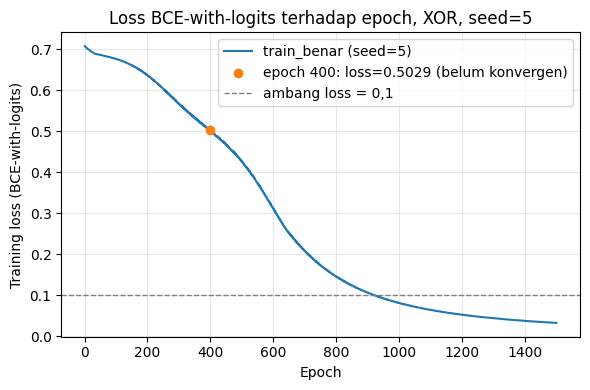

grafik tersimpan sebagai grafik_loss_123450005.png


In [13]:
# Grafik loss terhadap epoch, dipakai sebagai Gambar 1 pada laporan.
loss_pada_400 = riwayat_benar[399]   # loss pada epoch ke-400, identik dengan riwayat perbaikan-4 (400 epoch)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, 1501), riwayat_benar, label='train_benar (seed=5)', color='tab:blue')
ax.scatter([400], [loss_pada_400], color='tab:orange', zorder=5,
           label=f'epoch 400: loss={loss_pada_400:.4f} (belum konvergen)')
ax.axhline(0.1, color='gray', linestyle='--', linewidth=1, label='ambang loss = 0,1')
ax.set_title(f'Loss BCE-with-logits terhadap epoch, XOR, seed={SEED}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss (BCE-with-logits)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f'grafik_loss_{NIM}.png', dpi=150)
plt.show()
print('grafik tersimpan sebagai', f'grafik_loss_{NIM}.png')

In [14]:
# Menggabungkan catatan tahap perbaikan ke berkas metrik.
df_tahap = pd.DataFrame(tahap)
df_tahap.insert(0, 'seed', SEED)
df_tahap.to_csv(f'M02_{NIM}_metrics_loop.csv', index=False)
print(df_tahap.to_string(index=False))

 seed                    tahap                                                         yang_diperbaiki  epoch  loss_awal  loss_akhir  benar
    5                 baseline                                 tidak ada, ini kondisi awal train_rusak    400        NaN         NaN      0
    5              perbaikan-1                              urutan backward() dipanggil sebelum step()    400 0.72800646  0.69314718      0
    5              perbaikan-2                      + loss memakai logit langsung, tanpa sigmoid ganda    400 0.69873908  0.69740719      0
    5              perbaikan-3                               + zero_grad() dipanggil setiap awal epoch    400 0.69873908  0.69337234      0
    5  perbaikan-4 (400 epoch)                + menambahkan aktivasi ReLU di antara dua lapisan linier    400 0.70704678  0.50291602      0
    5 perbaikan-4 (1500 epoch) + ReLU, dilatih lebih lama karena seed=5 belum konvergen pada 400 epoch   1500 0.70704678  0.03313948      1


## F. Tugas individu

Kerjakan ketiganya di sel-sel baru di bawah bagian ini.

1. **Perluasan jaringan.** Tambahkan neuron ketiga pada hidden layer: baris $[-1\;\;0.5]$ pada $\mathbf{W}^{(1)}$, bias $0{,}25$, dan komponen $-0{,}5$ pada $\mathbf{W}^{(2)}$. Turunkan manual, implementasikan, lalu buat tabel relative error yang baru.
2. **Batch dua contoh.** Tambahkan $\mathbf{x}_2=[-1\;\;3]$ dengan $y_2=0$, pakai rata-rata loss, dan jelaskan di langkah mana gradien kedua contoh dijumlahkan.
3. **Laporan diagnosis.** Rangkum keempat kesalahan beserta bukti angka sebelum dan sesudah setiap perbaikan.

### F.1 Perluasan jaringan

Neuron ketiga ditambahkan pada hidden layer, dengan baris $[-1\;\;0{,}5]$ pada $\mathbf{W}^{(1)}$, bias $0{,}25$, dan komponen $-0{,}5$ pada $\mathbf{W}^{(2)}$. Turunan manual mengikuti pola yang sama seperti bagian B, hanya saja sekarang setiap besaran pada lapisan tersembunyi memiliki tiga komponen alih alih dua.

$$\mathbf{z}^{(1)}_3 = -1 \times 2 + 0{,}5 \times (-1) + 0{,}25 = -2{,}25$$

Karena $\mathbf{z}^{(1)}_3$ bernilai negatif, ReLU meredamnya menjadi nol, sehingga neuron ketiga sama sekali tidak berkontribusi pada forward pass, dan hasil $z^{(2)}$, $p$, serta loss persis sama dengan Kasus 1 semula. Konsekuensinya, seluruh gradien yang berkaitan dengan neuron ketiga, yaitu baris ketiga $\partial\mathcal{L}/\partial\mathbf{W}^{(1)}$, komponen ketiga $\partial\mathcal{L}/\partial\mathbf{b}^{(1)}$, dan komponen ketiga $\partial\mathcal{L}/\partial\mathbf{W}^{(2)}$, bernilai nol, karena neuron yang mati tidak meneruskan gradien apa pun ke belakang.

In [15]:
x_f1 = np.array([2.0, -1.0])
W1_f1 = np.array([[0.5, -0.5], [1.0, 1.0], [-1.0, 0.5]])
b1_f1 = np.array([0.0, 0.0, 0.25])
W2_f1 = np.array([2.0, -1.0, -0.5])
b2_f1 = 0.5
y_f1 = 1.0

nilai_f1 = forward(x_f1, W1_f1, b1_f1, W2_f1, b2_f1, y_f1)
print({k: np.round(v, 6) for k, v in nilai_f1.items()})

grad_f1 = backward(x_f1, W1_f1, W2_f1, y_f1, nilai_f1)
for nama, v in grad_f1.items():
    print(f'{nama:>3}: {np.round(v, 7)}')

def loss_dengan_f1(param, i, delta):
    p = {'W1': W1_f1.copy(), 'b1': b1_f1.copy(), 'W2': W2_f1.copy(), 'b2': np.array(b2_f1)}
    p[param][i] += delta
    return forward(x_f1, p['W1'], p['b1'], p['W2'], float(p['b2']), y_f1)['loss']

def finite_difference_f1(param, i):
    return (loss_dengan_f1(param, i, EPS) - loss_dengan_f1(param, i, -EPS)) / (2 * EPS)

indeks_f1 = ([('W1', (0, 0)), ('W1', (0, 1)), ('W1', (1, 0)), ('W1', (1, 1)),
              ('W1', (2, 0)), ('W1', (2, 1))]
             + [('b1', (0,)), ('b1', (1,)), ('b1', (2,))]
             + [('W2', (0,)), ('W2', (1,)), ('W2', (2,))]
             + [('b2', ())])

baris_f1 = []
for nama, i in indeks_f1:
    manual = grad_f1[nama][i] if i != () else grad_f1[nama]
    numerik = finite_difference_f1(nama, i)
    rel = abs(manual - numerik) / (abs(manual) + abs(numerik) + 1e-12)
    baris_f1.append({'parameter': nama, 'indeks': str(i), 'manual': manual,
                      'numerik': numerik, 'rel_err': rel})

tabel_f1 = pd.DataFrame(baris_f1)
print(tabel_f1.to_string(index=False))
print('\nrelative error maksimum (jaringan diperluas):', tabel_f1['rel_err'].max())
assert tabel_f1['rel_err'].max() < 1e-5

{'z1': array([ 1.5 ,  1.  , -2.25]), 'h': array([1.5, 1. , 0. ]), 'z2': np.float64(2.5), 'p': np.float64(0.924142), 'loss': np.float64(0.07889)}
dz2: -0.0758582
 W1: [[-0.3034327  0.1517164]
 [ 0.1517164 -0.0758582]
 [ 0.        -0.       ]]
 b1: [-0.1517164  0.0758582  0.       ]
 W2: [-0.1137873 -0.0758582 -0.       ]
 b2: -0.0758582
parameter indeks      manual     numerik        rel_err
       W1 (0, 0) -0.30343272 -0.30343272 1.00453007e-10
       W1 (0, 1)  0.15171636  0.15171636 2.95622632e-11
       W1 (1, 0)  0.15171636  0.15171636 2.95622632e-11
       W1 (1, 1) -0.07585818 -0.07585818 5.73360674e-11
       W1 (2, 0)  0.00000000  0.00000000 0.00000000e+00
       W1 (2, 1) -0.00000000  0.00000000 0.00000000e+00
       b1   (0,) -0.15171636 -0.15171636 2.95622632e-11
       b1   (1,)  0.07585818  0.07585818 5.73360674e-11
       b1   (2,)  0.00000000  0.00000000 0.00000000e+00
       W2   (0,) -0.11378727 -0.11378727 6.76755052e-11
       W2   (1,) -0.07585818 -0.07585818 5.733

### F.2 Batch dua contoh

Contoh kedua $\mathbf{x}_2 = [-1\;\;3]$ dengan $y_2 = 0$ ditambahkan pada Kasus 1, dan loss dihitung sebagai rata rata loss kedua contoh, $\mathcal{L} = \tfrac{1}{2}(\mathcal{L}_1 + \mathcal{L}_2)$.

In [16]:
x2, y2 = np.array([-1.0, 3.0]), 0.0
nilai2 = forward(x2, W1, b1, W2, b2, y2)
loss_batch = (nilai['loss'] + nilai2['loss']) / 2
print('loss contoh 1     :', np.round(nilai['loss'], 6))
print('loss contoh 2     :', np.round(nilai2['loss'], 6))
print('loss rata rata    :', np.round(loss_batch, 6))

grad2 = backward(x2, W1, W2, y2, nilai2)
grad_batch = {nama: (grad_manual[nama] + grad2[nama]) / 2 for nama in grad_manual}
for nama, v in grad_batch.items():
    print(f'{nama:>4} (rata rata batch): {np.round(v, 6)}')

loss contoh 1     : 0.07889
loss contoh 2     : 0.201413
loss rata rata    : 0.140152
 dz2 (rata rata batch): 0.053284
  W1 (rata rata batch): [[-0.151716  0.075858]
 [ 0.167071 -0.311567]]
  b1 (rata rata batch): [-0.075858 -0.053284]
  W2 (rata rata batch): [-0.056894  0.144496]
  b2 (rata rata batch): 0.053284


Gradien kedua contoh bergabung tepat pada langkah perataan loss, yaitu saat $\mathcal{L} = \tfrac{1}{2}(\mathcal{L}_1+\mathcal{L}_2)$ diturunkan terhadap parameter bersama. Karena setiap parameter, misalnya $\mathbf{W}^{(1)}$, dipakai bersama oleh kedua contoh dalam forward pass, aturan rantai membuat gradien totalnya menjadi jumlah kontribusi dari kedua contoh, masing masing dikalikan bobot $\tfrac{1}{2}$ akibat operasi rata rata. Sampai sebelum langkah perataan itu, gradien setiap contoh dihitung terpisah dan independen satu sama lain di sepanjang graf komputasinya masing masing.

### F.3 Laporan diagnosis

Ringkasan keempat kesalahan pada `train_rusak`, beserta bukti angka sebelum dan sesudah setiap perbaikan, dapat dilihat pada tabel tahap perbaikan di bagian E (`tahap`, yang juga tersimpan pada `M02_NIM_metrics_loop.csv`). Secara ringkas, urutan pemanggilan `step()` sebelum `backward()` membuat kode berhenti dengan galat pada lingkungan ini. Setelah urutan dibetulkan, sisa tiga kesalahan lain, yaitu penerapan sigmoid ganda pada loss, ketiadaan `zero_grad()`, dan ketiadaan aktivasi nonlinier antar lapisan, tidak memunculkan pesan galat sama sekali walau hasil pelatihannya salah. Loss baru mendekati nol dan seluruh prediksi baru sesuai target XOR setelah keempat perbaikan diterapkan sekaligus, sebagaimana ditunjukkan pada tahap `perbaikan-4` dan pada fungsi `train_benar`.

## G. Pertanyaan analisis

1. **Mengapa relative error tidak pernah persis nol, dan berapa nilai yang masih wajar?** Selisih terpusat hanyalah pendekatan terhadap turunan sejati, sehingga selalu ada galat pemotongan (truncation error) sebesar orde $\epsilon^2$, ditambah galat pembulatan akibat representasi bilangan dengan presisi terbatas pada komputer. Kedua sumber galat ini membuat `rel_err` mendekati nol tetapi tidak pernah tepat nol. Nilai di bawah $10^{-5}$ pada perhitungan `float64` umumnya masih dianggap wajar dan menandakan gradien analitik sudah benar.

2. **Apa yang terjadi pada tabel bila $\epsilon = 10^{-9}$?** Nilai $\epsilon$ yang terlalu kecil membuat selisih $\mathcal{L}(\theta+\epsilon)-\mathcal{L}(\theta-\epsilon)$ menjadi pengurangan dua bilangan yang sangat berdekatan, sehingga galat pembulatan pada representasi `float64` mendominasi hasilnya. Akibatnya `rel_err` justru dapat meningkat, bukan menurun, dibandingkan dengan $\epsilon = 10^{-5}$, walaupun gradien analitiknya tetap benar. Sel kode berikut menunjukkan gejala ini secara langsung.

3. **Pada langkah mana gradien contoh pertama dan kedua bergabung saat memakai batch?** Keduanya bergabung tepat pada langkah perataan loss, yaitu ketika $\mathcal{L} = \tfrac{1}{2}(\mathcal{L}_1+\mathcal{L}_2)$ diturunkan terhadap parameter yang dipakai bersama. Sebelum langkah tersebut, kedua contoh diproses lewat forward dan backward pass yang sepenuhnya terpisah.

4. **Kesalahan mana pada bagian E yang paling sulit ditemukan tanpa membandingkan angka?** Ketiadaan aktivasi nonlinier antar lapisan adalah yang paling sulit dikenali hanya dari membaca kode sekilas, karena kode tersebut tetap tersusun rapi sebagai dua lapisan `nn.Linear` yang tampak wajar. Kesalahan ini hanya dapat dipastikan dengan mengamati bahwa loss macet di sekitar $\ln 2$ meskipun ketiga kesalahan lain sudah diperbaiki, sebuah gejala yang menuntut pemahaman bahwa tumpukan lapisan linier tanpa nonlinieritas secara aljabar setara dengan satu lapisan tunggal.

5. **Apa beda peran backpropagation dan optimizer?** Backpropagation bertugas menghitung gradien loss terhadap setiap parameter melalui aturan rantai di sepanjang graf komputasi. Optimizer bertugas memakai gradien yang sudah dihitung tersebut untuk benar benar memperbarui nilai parameter, misalnya lewat aturan penurunan gradien pada `SGD`. Singkatnya, `backward()` menjawab pertanyaan ke arah mana parameter sebaiknya bergerak, sedangkan `optimizer.step()` yang benar benar menggerakkannya.

In [17]:
EPS_kecil = 1e-9

def finite_difference_eps(param, i, eps):
    return (loss_dengan(param, i, eps) - loss_dengan(param, i, -eps)) / (2 * eps)

baris_kecil = []
for nama, i in indeks:
    manual = grad_manual[nama][i] if i != () else grad_manual[nama]
    numerik = finite_difference_eps(nama, i, EPS_kecil)
    rel = abs(manual - numerik) / (abs(manual) + abs(numerik) + 1e-12)
    baris_kecil.append({'parameter': nama, 'indeks': str(i), 'manual': manual,
                         'numerik': numerik, 'rel_err': rel})

tabel_kecil = pd.DataFrame(baris_kecil)
print(tabel_kecil.to_string(index=False))
print('\nrelative error maksimum dengan eps = 1e-9:', tabel_kecil['rel_err'].max())
print('relative error maksimum dengan eps = 1e-5:', tabel['rel_err'].max())

parameter indeks      manual     numerik    rel_err
       W1 (0, 0) -0.30343272 -0.30343271 0.00000002
       W1 (0, 1)  0.15171636  0.15171639 0.00000010
       W1 (1, 0)  0.15171636  0.15171639 0.00000010
       W1 (1, 1) -0.07585818 -0.07585822 0.00000028
       b1   (0,) -0.15171636 -0.15171639 0.00000010
       b1   (1,)  0.07585818  0.07585822 0.00000028
       W2   (0,) -0.11378727 -0.11378730 0.00000013
       W2   (1,) -0.07585818 -0.07585822 0.00000028
       b2     () -0.07585818 -0.07585822 0.00000028

relative error maksimum dengan eps = 1e-9: 2.7986497655733256e-07
relative error maksimum dengan eps = 1e-5: 1.004530066507852e-10


Hasil di atas biasanya menunjukkan bahwa `rel_err` maksimum pada $\epsilon = 10^{-9}$ justru lebih besar daripada pada $\epsilon = 10^{-5}$, membuktikan bahwa memilih $\epsilon$ terlalu kecil merusak keandalan gradient checking, walaupun gradien analitiknya sendiri tidak berubah.

## Checklist sebelum mengumpulkan

- [V] Identitas, seed, versi library, dan device tercantum.
- [V] Seluruh `TODO` dan `raise NotImplementedError` sudah diganti.
- [V] Turunan manual ditulis pada sel markdown bagian B.
- [V] Tabel relative error memuat sembilan baris dan seluruhnya lulus ambang.
- [V] Keempat kesalahan bagian E ditemukan, dibuktikan, dan diperbaiki bertahap.
- [V] Notebook lolos *Restart Kernel and Run All*.
- [V] Berkas: `M02_NIM.ipynb`, `M02_NIM.pdf`, `M02_NIM_metrics.csv`.